In [ ]:
### this script is used to analyze the speed as animals traverese the VR
### JSY, 05/2025

In [170]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy.ndimage import gaussian_filter1d
from scipy import stats
from itertools import groupby
from operator import itemgetter

def load_treadmill_data(treadmill_file_path):
    """
    Load treadmill encoder data with time, distance, speed
    Handles the case where treadmill data is logged only when there's a change
    """
    # Initialize lists to store data
    times = []
    distances = []
    speeds = []
    
    # Read the file
    with open(treadmill_file_path, 'r') as file:
        lines = file.readlines()
        
        # Skip header lines
        data_start = 0
        for i, line in enumerate(lines):
            if "Log format is current time distance speed" in line:
                data_start = i + 1
                break
        
        # Process each data line
        for line in lines[data_start:]:
            parts = line.strip().split()
            if len(parts) >= 3:  # Ensure we have time, distance, and speed
                try:
                    time_str = parts[0]
                    distance = float(parts[1])
                    speed = float(parts[2])
                    
                    # Convert time string to datetime
                    time_obj = datetime.datetime.strptime(time_str, '%H.%M.%S.%f')
                    
                    times.append(time_obj)
                    distances.append(distance)
                    speeds.append(speed)
                except (ValueError, IndexError):
                    continue  # Skip malformed lines
    
    # Convert to numpy arrays
    times = np.array(times)
    distances = np.array(distances)
    speeds = np.array(speeds)
    
    # Calculate relative times (seconds from start)
    if len(times) > 0:
        start_time = times[0]
        rel_times = np.array([(t - start_time).total_seconds() for t in times])
    else:
        rel_times = np.array([])
    
    print(f"Loaded {len(times)} treadmill data points")
    
    return {
        'abs_times': times,
        'rel_times': rel_times,
        'distances': distances,
        'speeds': speeds
    }

def load_VR_data(VRlog_path):
    """
    Load VR/behavior data at regular intervals
    """
    # Read the VR log file
    rawVR_data = []
    with open(VRlog_path, "r") as file:
        lines = file.readlines()
        # Skip header lines (first 3 lines typically)
        for line in lines[3:]:
            rawVR_data.append(line.strip().split("\t"))
    
    # Extract data - handle different formats for safety
    vr_abs_times = []
    vr_rel_times = []
    vr_events = []
    vr_locations = []
    
    for line in rawVR_data:
        if len(line) >= 4:  # Basic sanity check
            vr_abs_times.append(line[0])
            vr_rel_times.append(float(line[1]) if line[1].replace('.','',1).isdigit() else 0)
            vr_events.append(line[2])
            
            # Check which column has location data based on event type
            if line[2] == 'p' and len(line) >= 6:
                vr_locations.append(float(line[5]) if line[5].replace('.','',1).replace('-','',1).isdigit() else 0)
            else:
                vr_locations.append(float(line[3]) if line[3].replace('.','',1).replace('-','',1).isdigit() else 0)
    
    # Convert to numpy arrays
    vr_abs_times = np.array(vr_abs_times)
    vr_rel_times = np.array(vr_rel_times)
    vr_events = np.array(vr_events)
    vr_locations = np.array(vr_locations)
    
    # Find the first 's' event (start signal)
    s_indices = np.where(vr_events == 's')[0]
    if len(s_indices) > 0:
        start_index = s_indices[0]
        # Truncate arrays to start at the 's' event
        vr_abs_times = vr_abs_times[start_index:]
        vr_rel_times = vr_rel_times[start_index:]
        vr_events = vr_events[start_index:]
        vr_locations = vr_locations[start_index:]
    
    # Parse absolute times
    abs_times = []
    for t_str in vr_abs_times:
        try:
            time_obj = datetime.datetime.strptime(t_str, '%H.%M.%S.%f')
            abs_times.append(time_obj)
        except ValueError:
            # Handle parsing errors
            if abs_times:
                abs_times.append(abs_times[-1])
            else:
                abs_times.append(datetime.datetime.now())  # Placeholder
    
    abs_times = np.array(abs_times)
    
    print(f"Loaded {len(vr_abs_times)} VR data points")
    
    return {
        'abs_times': abs_times,
        'rel_times': vr_rel_times,
        'events': vr_events,
        'locations': vr_locations,
        'raw_abs_times': vr_abs_times  # Keep original string format
    }

def align_treadmill_VR_data(treadmill_data, vr_data):
    """
    Align treadmill and VR datasets based on absolute timestamps
    and convert VR locations to proper distances in cm
    """
    # Get absolute times from both datasets
    treadmill_abs_times = treadmill_data['abs_times']
    vr_abs_times = vr_data['abs_times']
    
    if len(treadmill_abs_times) == 0 or len(vr_abs_times) == 0:
        print("Error: One or both datasets are empty")
        return None
    
    # Calculate time offset between the two datasets
    treadmill_start = treadmill_abs_times[0]
    vr_start = vr_abs_times[0]
    time_offset = (treadmill_start - vr_start).total_seconds()
    
    print(f"Time offset between datasets: {time_offset:.3f} seconds")
    print(f"Treadmill data starts at: {treadmill_start}")
    print(f"VR data starts at: {vr_start}")
    
    # Find index of treadmill time closest to the offset (from test script)
    closest_index = np.argmin(np.abs(treadmill_data['rel_times'] - time_offset))
    print(f"Closest index in treadmill data to time offset: {closest_index}")
    print(f"Closest treadmill relative time to offset: {treadmill_data['rel_times'][closest_index]}")
    
    # Truncate treadmill data to align with VR data
    treadmill_abs_times = treadmill_abs_times[closest_index:]
    treadmill_rel_times = treadmill_data['rel_times'][closest_index:]
    treadmill_distances = treadmill_data['distances'][closest_index:]
    treadmill_speeds = treadmill_data['speeds'][closest_index:]
    
    # Constants for VR-to-cm conversion (from spatial discretization)
    single_revolution_VR = 282.415
    single_revolution_treadmill = 27.8
    single_lap_VR = 1320.645683  # Adjust based on your specific VR environment
    single_lap_treadmill = single_revolution_treadmill * single_lap_VR / single_revolution_VR
    
    print(f"Converting VR locations to cm using single_lap_treadmill = {single_lap_treadmill:.2f} cm")
    
    # Convert VR locations to cm
    raw_locations = vr_data['locations']
    
    # Find the range of VR locations
    min_loc = np.min(raw_locations)
    max_loc = np.max(raw_locations)
    location_range = max_loc - min_loc
    
    # Scale and shift to match real-world distances
    locations_cm = (raw_locations - min_loc) / location_range * single_lap_treadmill
    
    print(f"Original VR location range: {min_loc:.2f} to {max_loc:.2f}")
    print(f"Converted position range: 0.00 to {single_lap_treadmill:.2f} cm")
    
    # Interpolate treadmill data (distance, speed) to VR time points
    interp_distances = np.interp(
        vr_data['rel_times'],
        treadmill_rel_times,
        treadmill_distances,
        left=np.nan,
        right=np.nan
    )
    
    interp_speeds = np.interp(
        vr_data['rel_times'],
        treadmill_rel_times,
        treadmill_speeds,
        left=np.nan,
        right=np.nan
    )
    print(f"size of interp_speeds: {np.shape(interp_speeds)} and size of interp_distances: {np.shape(interp_distances)}")
    
    # Combine the datasets
    aligned_data = {
        'times': vr_data['rel_times'],
        'locations': locations_cm,  # Converted to cm
        'raw_locations': raw_locations,  # Keep original for reference
        'distances': interp_distances,
        'speeds': interp_speeds,
        'events': vr_data['events'],
        'time_offset': time_offset,
        'conversion_factor': single_lap_treadmill / location_range,
        'lap_length_cm': single_lap_treadmill
    }
    
    return aligned_data

def remove_inactive_periods(aligned_data, min_speed=10.0, min_duration_sec=0.5):
    """
    Remove inactive periods where the animal isn't moving
    """
    # Extract data
    times = aligned_data['times']
    locations = aligned_data['locations']
    speeds = aligned_data['speeds']
    
    # Create activity mask based on speed threshold
    activity_mask = speeds >= min_speed
    
    # Handle small gaps - fill in short inactive periods
    from scipy import ndimage
    
    # Convert duration to number of samples
    # Estimate sampling rate from time differences
    if len(times) > 1:
        avg_dt = np.mean(np.diff(times))
        samples_threshold = int(min_duration_sec / avg_dt)
        # Fill small gaps
        filled_mask = ndimage.binary_closing(activity_mask, structure=np.ones(samples_threshold))
    else:
        filled_mask = activity_mask
    
    # Apply mask to all data arrays
    filtered_data = {
        'times': times[filled_mask],
        'locations': locations[filled_mask],
        'speeds': speeds[filled_mask],
    }
    
    # If distances are available, include them
    if 'distances' in aligned_data:
        filtered_data['distances'] = aligned_data['distances'][filled_mask]
    
    # Calculate removal statistics
    removed_points = len(times) - len(filtered_data['times'])
    removed_pct = removed_points / len(times) * 100
    
    print(f"Removed {removed_points} inactive data points ({removed_pct:.1f}%)")
    print(f"Retained {len(filtered_data['times'])} active data points")
    
    return filtered_data

def reshape_into_laps(location, speed, high_percentile=90, low_percentile=10, plot_detection=True):
    """
    Reshape location and speed data into laps using percentile-based 
    thresholds for more robust lap detection. From the test script.
    
    Parameters:
    -----------
    location : numpy.ndarray
        Location data (time,)
    speed : numpy.ndarray
        Speed data (time,)
    high_percentile : float, optional
        Percentile value to use for high threshold (default: 90)
    low_percentile : float, optional
        Percentile value to use for low threshold (default: 10)
    plot_detection : bool, optional
        Whether to plot the lap detection result (default: True)
        
    Returns:
    --------
    location_laps : list
        List of numpy arrays containing location data for each lap
    speed_laps : list
        List of numpy arrays containing speed data for each lap
    n_laps : int
        Number of laps detected
    """
    # Find thresholds based on percentiles instead of absolute values
    threshold_high = np.percentile(location, high_percentile)
    threshold_low = np.percentile(location, low_percentile)
    
    print(f"Location range: {np.min(location):.2f} to {np.max(location):.2f}")
    print(f"Using high threshold: {threshold_high:.2f} (at {high_percentile}th percentile)")
    print(f"Using low threshold: {threshold_low:.2f} (at {low_percentile}th percentile)")
    
    # Find the first minimum in the data
    first_min_indices = np.where(location < threshold_low)[0]
    if len(first_min_indices) == 0:
        print("No location values below low threshold found!")
        return None, None, 0
    first_min_idx = first_min_indices[0]
    print(f"First minimum index: {first_min_idx}")
    
    # Use a state machine approach to identify transitions
    lap_ends = []
    state = "low" if location[0] < threshold_low else "high"
    
    for i in range(1, len(location)):
        if state == "high" and location[i] < threshold_low:
            lap_ends.append(i)
            state = "low"
        elif state == "low" and location[i] > threshold_high:
            state = "high"
    
    lap_ends = np.array(lap_ends)

    if len(lap_ends) == 0:
        print("No lap transitions detected!")
        return None, None, 0
        
    # Add start and end indices
    lap_starts = np.concatenate(([first_min_idx], lap_ends[1:]))
    lap_ends = np.concatenate((lap_ends[1:], [len(location)]))
    print(f"lap_stars: {lap_starts} and lap_ends: {lap_ends}")
    print(f"size of lap_starts: {np.shape(lap_starts)} and size of lap_ends: {np.shape(lap_ends)}")
    
    
    # Verify lap detection - ensure we have clear transitions
    valid_laps = []
    valid_starts = []
    valid_ends = []
    
    for i, (start, end) in enumerate(zip(lap_starts, lap_ends)):
        lap_loc = location[start:end]
        # Check if this lap has a clear high point and if there's any data
        if len(lap_loc) > 0 and np.max(lap_loc) > threshold_high:
            valid_laps.append(i)
            valid_starts.append(start)
            valid_ends.append(end)
    
    if len(valid_laps) < len(lap_starts):
        print(f"Removed {len(lap_starts) - len(valid_laps)} incomplete laps")
        lap_starts = np.array(valid_starts)
        lap_ends = np.array(valid_ends)
    
    # Calculate lap lengths
    lap_lengths = lap_ends - lap_starts
    n_laps = len(lap_starts)
    
    print(f"Found {n_laps} laps")
    print(f"Lap lengths: {lap_lengths}")

    # Create lists to store data for each lap
    location_laps = []
    speed_laps = []
    
    # Fill in the data with full lap lengths
    for start, end in zip(lap_starts, lap_ends):
        location_laps.append(location[start:end])
        speed_laps.append(speed[start:end])

    return location_laps, speed_laps, n_laps

def filter_inactive_periods_within_laps(location_laps, speed_laps, inactivity_threshold=1e-2, frames_to_keep=0):
    """
    Filter out inactive periods within each lap based on location changes
    From the test script
    """
    filtered_speed_laps = []
    filtered_location_laps = []
    
    for i in range(len(location_laps)):
        lap_speed = speed_laps[i]
        lap_loc = location_laps[i]
        
        # Detect inactivity within this lap based on location changes
        location_diff = np.abs(np.diff(lap_loc, n=5)) if len(lap_loc) > 5 else np.ones(len(lap_loc)-1)
        stationary_mask = np.pad(location_diff < inactivity_threshold, (0, 5), mode='constant')[:len(lap_loc)]
        stationary_indices = np.where(stationary_mask)[0]
        
        # Group consecutive stationary indices
        def group_consecutive(data):
            for k, g in groupby(enumerate(data), lambda x: x[0] - x[1]):
                yield list(map(itemgetter(1), g))
        
        stationary_periods = list(group_consecutive(stationary_indices))
        
        # Create mask for which frames to keep
        mask = np.ones(len(lap_loc), dtype=bool)
        
        for period in stationary_periods:
            if len(period) > 2 * frames_to_keep:
                start_idx = period[0]
                end_idx = period[-1]
                
                # Keep beginning and end, remove middle
                if start_idx + frames_to_keep < end_idx - frames_to_keep + 1:
                    mask[start_idx + frames_to_keep:end_idx - frames_to_keep + 1] = False
        
        # Apply mask
        filtered_speed_laps.append(lap_speed[mask])
        filtered_location_laps.append(lap_loc[mask])
    
    # Print summary of filtering
    for lap_idx in range(len(location_laps)):
        original_frames = len(location_laps[lap_idx])
        filtered_frames = len(filtered_location_laps[lap_idx])
        print(f"  Lap {lap_idx+1}: {filtered_frames}/{original_frames} frames kept " + 
              f"({filtered_frames/original_frames*100:.1f}%)")
    return filtered_location_laps, filtered_speed_laps
def spatial_discretize_speeds(filtered_location_laps, filtered_speed_laps, n_bins=100, 
                             smoothing_sigma=2, min_occupancy=1):
    """
    Discretize speed data into spatial bins for each lap with smoothing to reduce noise.
    
    Parameters:
    -----------
    filtered_location_laps : list
        List of numpy arrays containing location data for each lap
    filtered_speed_laps : list
        List of numpy arrays containing speed data for each lap
    n_bins : int
        Number of spatial bins to use (fewer bins = less noise)
    smoothing_sigma : float
        Sigma parameter for Gaussian smoothing (higher = smoother)
    min_occupancy : int
        Minimum number of data points required in a bin
        
    Returns:
    --------
    spatial_speeds : numpy.ndarray
        Speed in each spatial bin for each lap (laps x bins)
    bin_centers : numpy.ndarray
        Centers of spatial bins
    spatial_occupancy : numpy.ndarray
        Number of timepoints in each spatial bin for each lap
    smoothed_speeds : numpy.ndarray
        Smoothed version of spatial_speeds
    """
    # Get dimensions
    n_laps = len(filtered_location_laps)
    
    # Create spatial bins (from 0 to 130 cm)
    spatial_bins = np.linspace(0, 130, n_bins + 1)
    bin_centers = (spatial_bins[:-1] + spatial_bins[1:]) / 2
    
    # Initialize arrays
    spatial_speeds = np.zeros((n_laps, n_bins))
    spatial_occupancy = np.zeros((n_laps, n_bins))
    
    # Process each lap
    for lap_idx, (lap_location, lap_speed) in enumerate(zip(filtered_location_laps, filtered_speed_laps)):
        # Use histogram for binning
        hist, _ = np.histogram(lap_location, bins=spatial_bins)
        
        # Use a weighted histogram for speeds
        speed_hist = np.zeros(n_bins)
        for bin_idx in range(n_bins):
            bin_mask = (lap_location >= spatial_bins[bin_idx]) & (lap_location < spatial_bins[bin_idx + 1])
            if np.any(bin_mask):
                speed_hist[bin_idx] = np.mean(lap_speed[bin_mask])
                spatial_occupancy[lap_idx, bin_idx] = np.sum(bin_mask)
        
        # Store raw binned speeds
        spatial_speeds[lap_idx] = speed_hist
    
    # Apply occupancy threshold and replace low-occupancy bins with NaN
    masked_speeds = np.copy(spatial_speeds)
    for lap_idx in range(n_laps):
        low_occupancy_mask = spatial_occupancy[lap_idx] < min_occupancy
        masked_speeds[lap_idx, low_occupancy_mask] = np.nan
    
    # Create smoothed version using Gaussian filter
    smoothed_speeds = np.zeros_like(spatial_speeds)
    for lap_idx in range(n_laps):
        # Get the valid (non-NaN) indices
        valid_mask = ~np.isnan(masked_speeds[lap_idx])
        
        if np.sum(valid_mask) > 3:  # Need at least a few valid points for interpolation
            # Interpolate NaN values for smoothing
            valid_indices = np.where(valid_mask)[0]
            valid_values = masked_speeds[lap_idx, valid_mask]
            
            # Create interpolator
            from scipy import interpolate
            f = interpolate.interp1d(valid_indices, valid_values, 
                                     bounds_error=False, fill_value=np.nan)
            
            # Apply interpolation to fill gaps
            x_indices = np.arange(n_bins)
            filled_speeds = f(x_indices)
            
            # Apply Gaussian smoothing only where we have valid data
            non_nan_mask = ~np.isnan(filled_speeds)
            if np.sum(non_nan_mask) > 0:
                temp_smoothed = np.copy(filled_speeds)
                temp_smoothed[non_nan_mask] = gaussian_filter1d(
                    filled_speeds[non_nan_mask], sigma=smoothing_sigma)
                smoothed_speeds[lap_idx] = temp_smoothed
            else:
                smoothed_speeds[lap_idx] = filled_speeds
        else:
            # Not enough valid points for this lap
            smoothed_speeds[lap_idx] = masked_speeds[lap_idx]
    
    # Visualize the result for a sample lap (e.g., lap 3)
    sample_lap = 5 if n_laps > 3 else 0
    
    plt.figure(figsize=(15, 20))
    
    # Create subplots
    plt.subplot(2, 1, 1)
    plt.title(f'Lap {sample_lap+1} Raw vs. Processed Speed Data')
    
    # Plot original data
    plt.plot(filtered_location_laps[sample_lap], filtered_speed_laps[sample_lap], 
             'b.', alpha=0.3, label='Original Data Points')
    
    # Plot binned speeds
    plt.plot(bin_centers, spatial_speeds[sample_lap], 
             'g-', linewidth=1.5, label='Binned Speed')
    
    # Plot smoothed speeds
    plt.plot(bin_centers, smoothed_speeds[sample_lap], 
             'r-', linewidth=2.5, label='Smoothed Speed')
    
    plt.xlabel('Position (cm)')
    plt.ylabel('Speed (mm/s)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot all laps smoothed
    plt.subplot(2, 1, 2)
    plt.title('Smoothed Speed Profiles for All Laps')
    
    # Plot each lap with a different color
    colors = plt.cm.viridis(np.linspace(0, 1, n_laps))
    for lap_idx in range(n_laps):
        plt.plot(bin_centers, smoothed_speeds[lap_idx], 
                 '-', color=colors[lap_idx], alpha=0.7,
                 linewidth=1, label=f'Lap {lap_idx+1}')
    
    # Plot average across all laps
    avg_speed = np.nanmean(smoothed_speeds, axis=0)
    plt.plot(bin_centers, avg_speed, 'k-', linewidth=3, label='Average')
    
    plt.xlabel('Position (cm)')
    plt.ylabel('Speed (mm/s)')
    plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Completed spatial discretization with {n_bins} bins and smoothing (sigma={smoothing_sigma})")
    return spatial_speeds, bin_centers, spatial_occupancy, smoothed_speeds

def analyze_speed_across_linearcorridor(spatial_speeds, bin_centers, smoothed_speeds, group_size=5):
    """
    Analyze speed profiles across the linear corridor using smoothed data.
    
    Parameters:
    -----------
    spatial_speeds : numpy.ndarray
        Raw speed in each spatial bin for each lap (laps x bins)
    bin_centers : numpy.ndarray
        Centers of spatial bins
    smoothed_speeds : numpy.ndarray
        Smoothed speed in each spatial bin for each lap (laps x bins)
    group_size : int
        Number of laps to group together for analysis
        
    Returns:
    --------
    dict : Dictionary containing analysis results
    """
    n_laps, n_bins = spatial_speeds.shape
    
    # Group laps and analyze trends
    n_groups = (n_laps + group_size - 1) // group_size
    
    # Calculate group averages using smoothed data
    group_avg_speeds = []
    group_labels = []
    
    for group_idx in range(n_groups):
        group_start = group_idx * group_size
        group_end = min((group_idx + 1) * group_size, n_laps)
        
        # Extract smoothed speeds for all laps in this group
        group_speeds = smoothed_speeds[group_start:group_end, :]
        
        # Calculate group average, handling NaNs
        group_avg = np.nanmean(group_speeds, axis=0)
        group_avg_speeds.append(group_avg)
        group_labels.append(f"Laps {group_start+1}-{group_end}")
    
    # ---- VISUALIZATION ----
    
    # Create figure for group analysis
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Average speed profile by group
    plt.subplot(2, 2, 1)
    
    # Colors for different groups
    colors = plt.cm.viridis(np.linspace(0, 1, n_groups))
    
    # Plot each group's average
    for group_idx, (avg_speed, label) in enumerate(zip(group_avg_speeds, group_labels)):
        plt.plot(bin_centers, avg_speed, '-', color=colors[group_idx], 
               linewidth=2, label=label)
    
    plt.title('Average Speed Profile by Lap Group')
    plt.xlabel('Position (cm)')
    plt.ylabel('Speed (mm/s)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Heatmap of all laps
    plt.subplot(2, 1, 2)
    
    # Use smoothed data for heatmap
    # Replace NaNs with zeros for better visualization
    heatmap_data = np.copy(smoothed_speeds)
    heatmap_data = np.nan_to_num(heatmap_data)
    
    # Create the heatmap
    im = plt.imshow(heatmap_data, aspect='auto', origin='lower', 
                 extent=[0, 130, 1, n_laps],
                 cmap='viridis')
    
    plt.colorbar(im, label='Speed (mm/s)')
    plt.title('Speed vs Position for All Laps')
    plt.xlabel('Position (cm)')
    plt.ylabel('Lap Number')
    
    # Add horizontal lines to mark lap groups
    for group_idx in range(1, n_groups):
        group_start = group_idx * group_size
        if group_start < n_laps:
            plt.axhline(group_start + 0.5, color='w', linestyle='-', alpha=0.5)
    
    # Plot 3: Average speed by lap number
    plt.subplot(2, 2, 2)
    
    # Calculate average speed for each lap across all bins
    lap_numbers = np.arange(1, n_laps + 1)
    avg_lap_speeds = np.nanmean(smoothed_speeds, axis=1)
    
    plt.plot(lap_numbers, avg_lap_speeds, 'o-', color='blue', alpha=0.7)
    
    # Add trend line
    if len(lap_numbers) > 2:
        # Filter out NaNs for fitting
        valid_mask = ~np.isnan(avg_lap_speeds)
        if np.sum(valid_mask) > 2:
            z = np.polyfit(lap_numbers[valid_mask], avg_lap_speeds[valid_mask], 1)
            p = np.poly1d(z)
            plt.plot(lap_numbers, p(lap_numbers), "r--", alpha=0.8, 
                    label=f"Trend: {z[0]:.2f}x + {z[1]:.2f}")
            
            # Calculate correlation
            corr, p_value = stats.pearsonr(lap_numbers[valid_mask], avg_lap_speeds[valid_mask])
            # plt.text(0.05, 0.95, f"Correlation: {corr:.2f}\np-value: {p_value:.3f}", 
            #         transform=plt.gca().transAxes, 
            #         bbox=dict(facecolor='white', alpha=0.5))
    
    plt.title('Average Speed by Lap')
    plt.xlabel('Lap Number')
    plt.ylabel('Average Speed (mm/s)')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Find positions of speed decrease
    # Calculate the overall average speed across all laps
    overall_avg_speed = np.nanmean(smoothed_speeds, axis=0)
    
    # Calculate derivative to find where speed changes
    speed_derivative = np.gradient(overall_avg_speed, bin_centers)
    
    # Create figure for overall analysis
    plt.figure(figsize=(12, 8))
    
    # Plot average speed across all laps
    plt.subplot(2, 1, 1)
    plt.plot(bin_centers, overall_avg_speed, 'b-', linewidth=2)
    plt.title('Average Speed Across All Laps')
    plt.xlabel('Position (cm)')
    plt.ylabel('Speed (mm/s)')
    plt.grid(True, alpha=0.3)
    
    # Plot speed derivative
    plt.subplot(2, 1, 2)
    plt.plot(bin_centers, speed_derivative, 'g-', linewidth=2)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    plt.title('Speed Derivative (Rate of Change)')
    plt.xlabel('Position (cm)')
    plt.ylabel('Speed Change Rate (mm/s²)')
    plt.grid(True, alpha=0.3)
    
    # Find regions of significant deceleration
    # Adaptive threshold based on data
    decel_threshold = np.percentile(speed_derivative, 10)  # 10th percentile
    print(f"Using deceleration threshold: {decel_threshold:.3f}")
    
    decel_indices = np.where(speed_derivative < decel_threshold)[0]
    decel_regions = bin_centers[decel_indices]
    
    if len(decel_regions) > 0:
        # Group adjacent deceleration points
        def group_consecutive(data, stepsize=1):
            return np.split(data, np.where(np.diff(data) > stepsize)[0] + 1)
        
        grouped_indices = group_consecutive(decel_indices)
        significant_regions = []
        
        for group in grouped_indices:
            if len(group) >= 3:  # At least 3 consecutive points
                start_idx = group[0]
                end_idx = group[-1]
                center_pos = bin_centers[start_idx + (end_idx - start_idx) // 2]
                significant_regions.append(center_pos)
                
                # Highlight deceleration regions on both plots
                for ax in plt.gcf().get_axes():
                    ax.axvspan(bin_centers[start_idx], bin_centers[end_idx], 
                              color='r', alpha=0.2)
                    # ax.axvspan(bin_centers[38], bin_centers[42], 
                    #           color='gray', alpha=0.1)
                # # Highlight deceleration regions on both plots
                # for ax in plt.gcf().get_axes():
                #     ax.axvspan(bin_centers[35:45],
                #             color='gray', alpha=0.2)
        # Annotate significant deceleration regions
        ax = plt.gcf().get_axes()[0]  # Top plot
        for pos in significant_regions:
            ax.annotate(f"{pos:.1f} cm", 
                       xy=(pos, np.interp(pos, bin_centers, overall_avg_speed)),
                       xytext=(0, 30), textcoords='offset points',
                       arrowprops=dict(arrowstyle="->", color='red', alpha=0.7),
                       ha='center')
                
        print(f"Found {len(significant_regions)} significant deceleration regions at positions: " + 
              ", ".join([f"{pos:.1f} cm" for pos in significant_regions]))
    else:
        print("No significant deceleration regions found.")
    
    plt.tight_layout()
    plt.show()
    
    # Return results
    return {
        'bin_centers': bin_centers,
        'spatial_speeds': spatial_speeds,
        'smoothed_speeds': smoothed_speeds,
        'group_avg_speeds': group_avg_speeds,
        'overall_avg_speed': overall_avg_speed,
        'speed_derivative': speed_derivative,
        'n_laps': n_laps,
        'significant_deceleration_regions': significant_regions if 'significant_regions' in locals() else []
    }
    
def run_comprehensive_analysis(treadmill_file_path, VRlog_path):
    """
    Run a comprehensive analysis of speed vs position along the track and across laps
    """
    # Step 1: Load data
    print("\n--- STEP 1: LOADING DATA ---")
    treadmill_data = load_treadmill_data(treadmill_file_path)
    vr_data = load_VR_data(VRlog_path)

    # Step 2: Align datasets
    print("\n--- STEP 2: ALIGNING DATASETS ---")
    aligned_data = align_treadmill_VR_data(treadmill_data, vr_data)
    if aligned_data is None:
        print("Error: Failed to align datasets")
        return None

    # Step 3: Remove inactive periods based on speed
    print("\n--- STEP 3: REMOVING INACTIVE PERIODS BASED ON SPEED ---")
    filtered_data = remove_inactive_periods(aligned_data, min_speed=5.0)

    # Step 4: Detect laps using reshape_into_laps
    print("\n--- STEP 4: DETECTING LAPS USING RESHAPE_INTO_LAPS ---")
    location_laps, speed_laps, n_laps = reshape_into_laps(
        filtered_data['locations'], 
        filtered_data['speeds'], 
        high_percentile=90, 
        low_percentile=10,
        plot_detection=True
    )

    if n_laps == 0:
        print("Error: No laps detected")
        return None

    # Step 5: Further filter inactive periods within each lap
    print("\n--- STEP 5: FILTERING INACTIVE PERIODS WITHIN LAPS ---")
    filtered_location_laps, filtered_speed_laps = filter_inactive_periods_within_laps(
        location_laps, 
        speed_laps, 
        inactivity_threshold=1e-2, 
        frames_to_keep=0
    )

    # Step 6: Discretize speeds into spatial bins with improved noise reduction
    print("\n--- STEP 6: DISCRETIZING SPEEDS INTO SPATIAL BINS WITH NOISE REDUCTION ---")
    spatial_speeds, bin_centers, spatial_occupancy, smoothed_speeds = spatial_discretize_speeds(
        filtered_location_laps,
        filtered_speed_laps,
        n_bins=100,  # Reduced from 130 for better smoothing
        smoothing_sigma=2,  # Adjust based on your needs
        min_occupancy=2  # Minimum number of points required in a bin
    )

    # Step 7: Analyze speed patterns across the linear corridor using smoothed data
    print("\n--- STEP 7: ANALYZING SPEED PATTERNS ACROSS LINEAR CORRIDOR ---")
    speed_analysis = analyze_speed_across_linearcorridor(
        spatial_speeds, 
        bin_centers, 
        smoothed_speeds,
        group_size=10  # Group laps by 5
    )

    # Create a results dictionary
    results = {
        'treadmill_data': treadmill_data,
        'vr_data': vr_data,
        'aligned_data': aligned_data,
        'filtered_data': filtered_data,
        'location_laps': location_laps,
        'speed_laps': speed_laps,
        'filtered_location_laps': filtered_location_laps,
        'filtered_speed_laps': filtered_speed_laps,
        'n_laps': n_laps,
        'spatial_speeds': spatial_speeds,
        'smoothed_speeds': smoothed_speeds,
        'bin_centers': bin_centers,
        'spatial_occupancy': spatial_occupancy,
        'speed_analysis': speed_analysis
    }

    # Print summary of key findings
    print("\n--- ANALYSIS SUMMARY ---")
    print(f"Total laps analyzed: {n_laps}")

    # Identify positions of significant speed decreases
    decel_regions = speed_analysis.get('significant_deceleration_regions', [])
    if len(decel_regions) > 0:
        print(f"Found {len(decel_regions)} positions with significant speed decrease:")
        for pos in decel_regions:
            print(f"  Position: {pos:.1f} cm")
    else:
        print("No significant speed decreases identified.")

    return results


--- STEP 1: LOADING DATA ---
Loaded 209784 treadmill data points
Loaded 520433 VR data points

--- STEP 2: ALIGNING DATASETS ---
Time offset between datasets: 0.966 seconds
Treadmill data starts at: 1900-01-01 02:19:00.895602
VR data starts at: 1900-01-01 02:18:59.929583
Closest index in treadmill data to time offset: 211
Closest treadmill relative time to offset: 0.952873
Converting VR locations to cm using single_lap_treadmill = 130.00 cm
Original VR location range: 14.13 to 364.09
Converted position range: 0.00 to 130.00 cm
size of interp_speeds: (520433,) and size of interp_distances: (520433,)

--- STEP 3: REMOVING INACTIVE PERIODS BASED ON SPEED ---
Removed 395995 inactive data points (76.1%)
Retained 124438 active data points

--- STEP 4: DETECTING LAPS USING RESHAPE_INTO_LAPS ---
Location range: 0.00 to 130.00
Using high threshold: 115.91 (at 90th percentile)
Using low threshold: 6.83 (at 10th percentile)
First minimum index: 72
lap_stars: [    72    193    502   1083   1588  

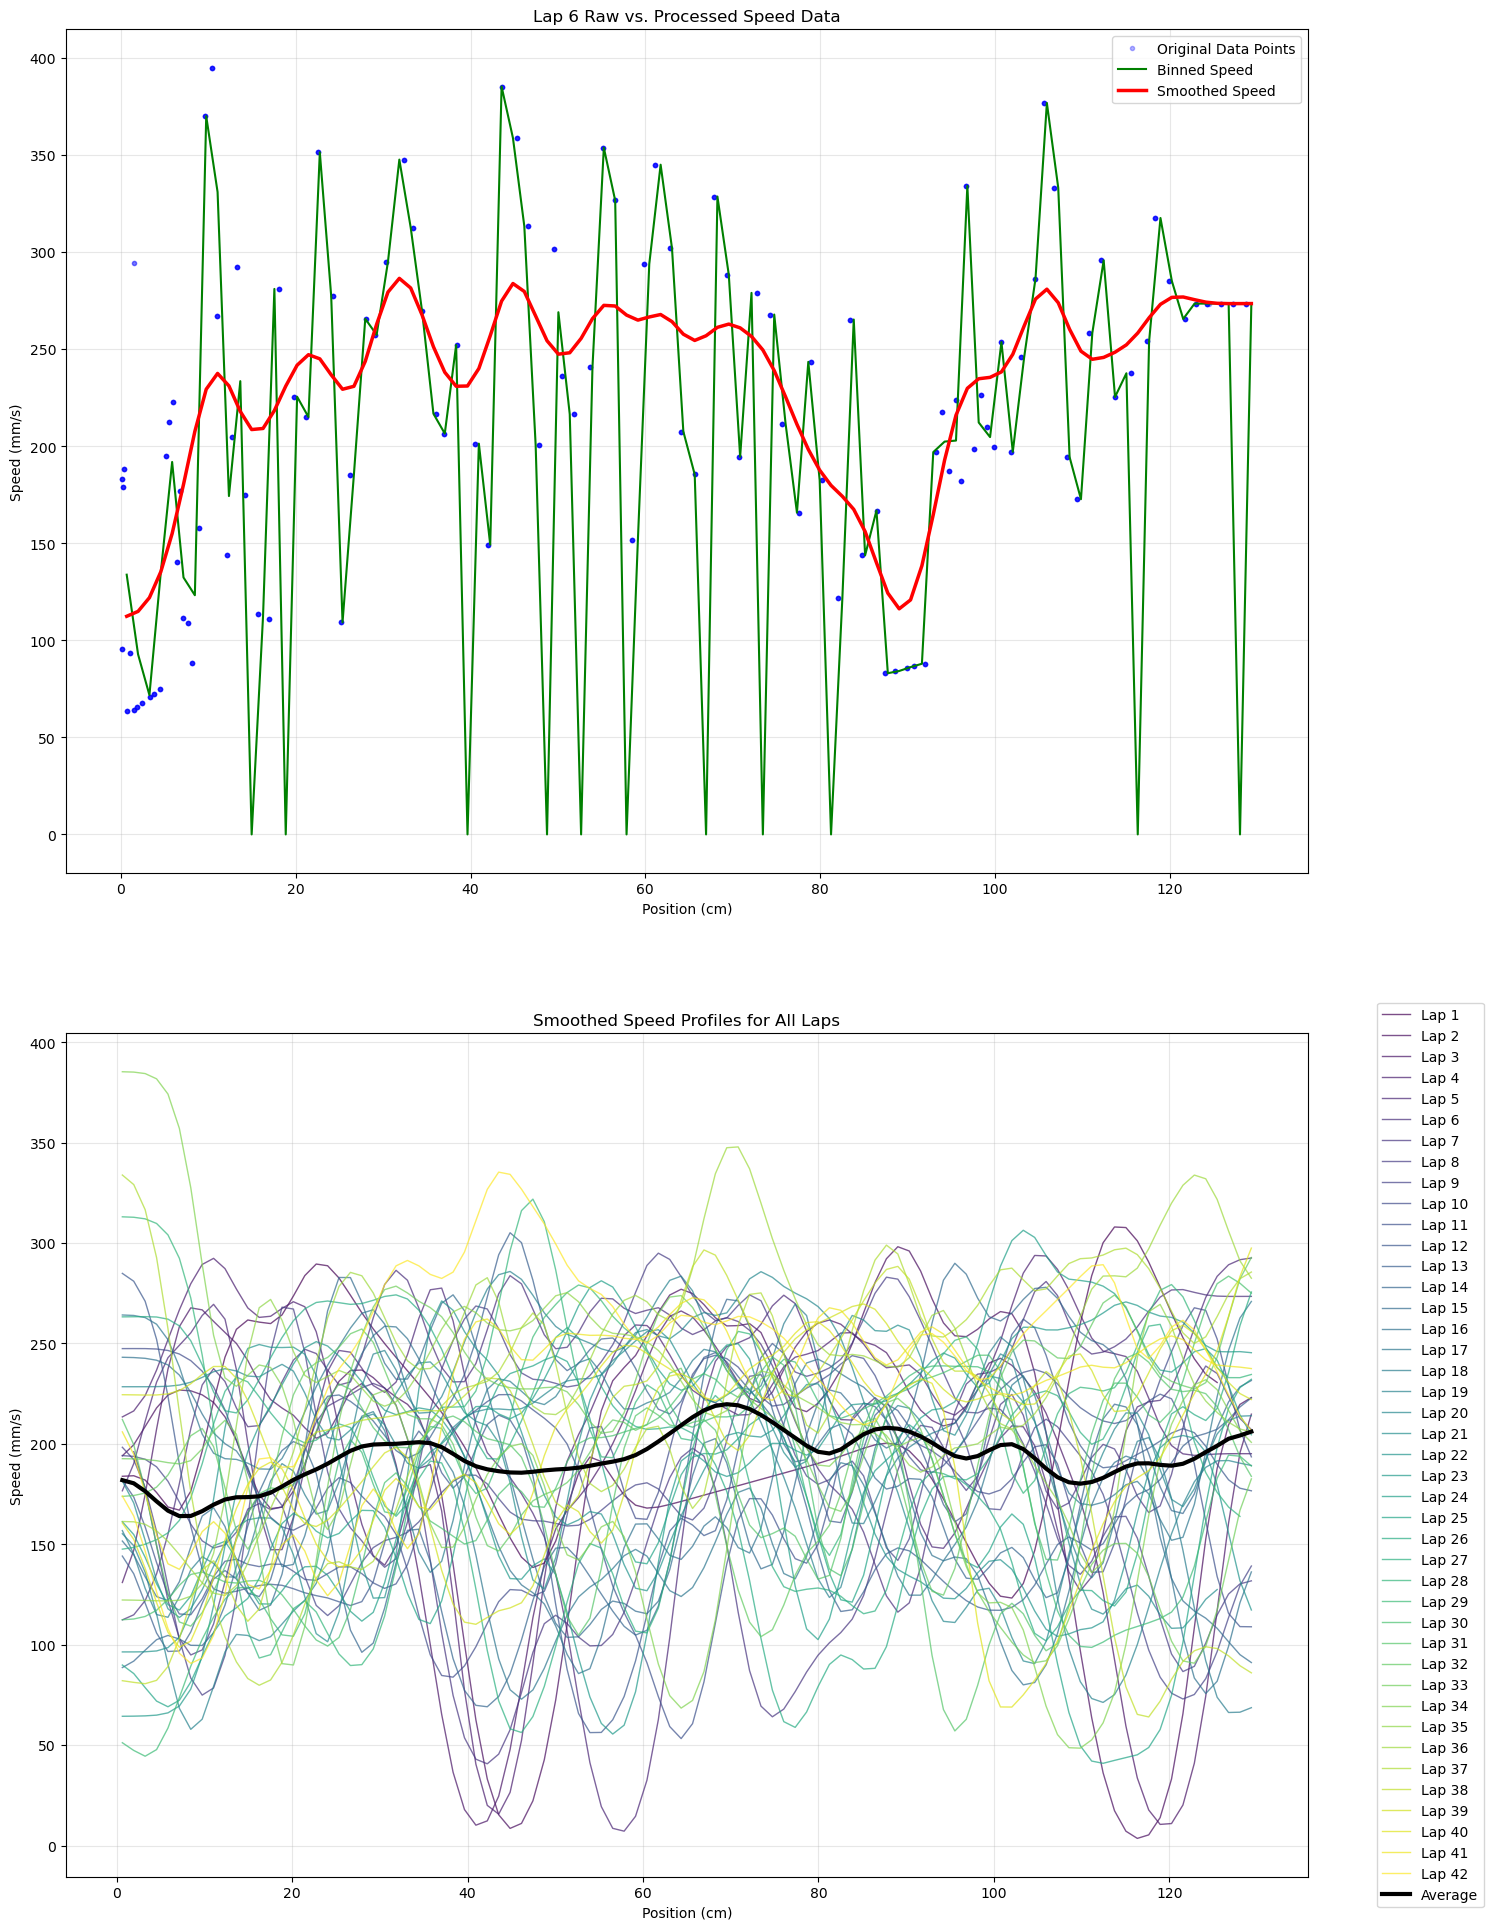

Completed spatial discretization with 100 bins and smoothing (sigma=2)

--- STEP 7: ANALYZING SPEED PATTERNS ACROSS LINEAR CORRIDOR ---


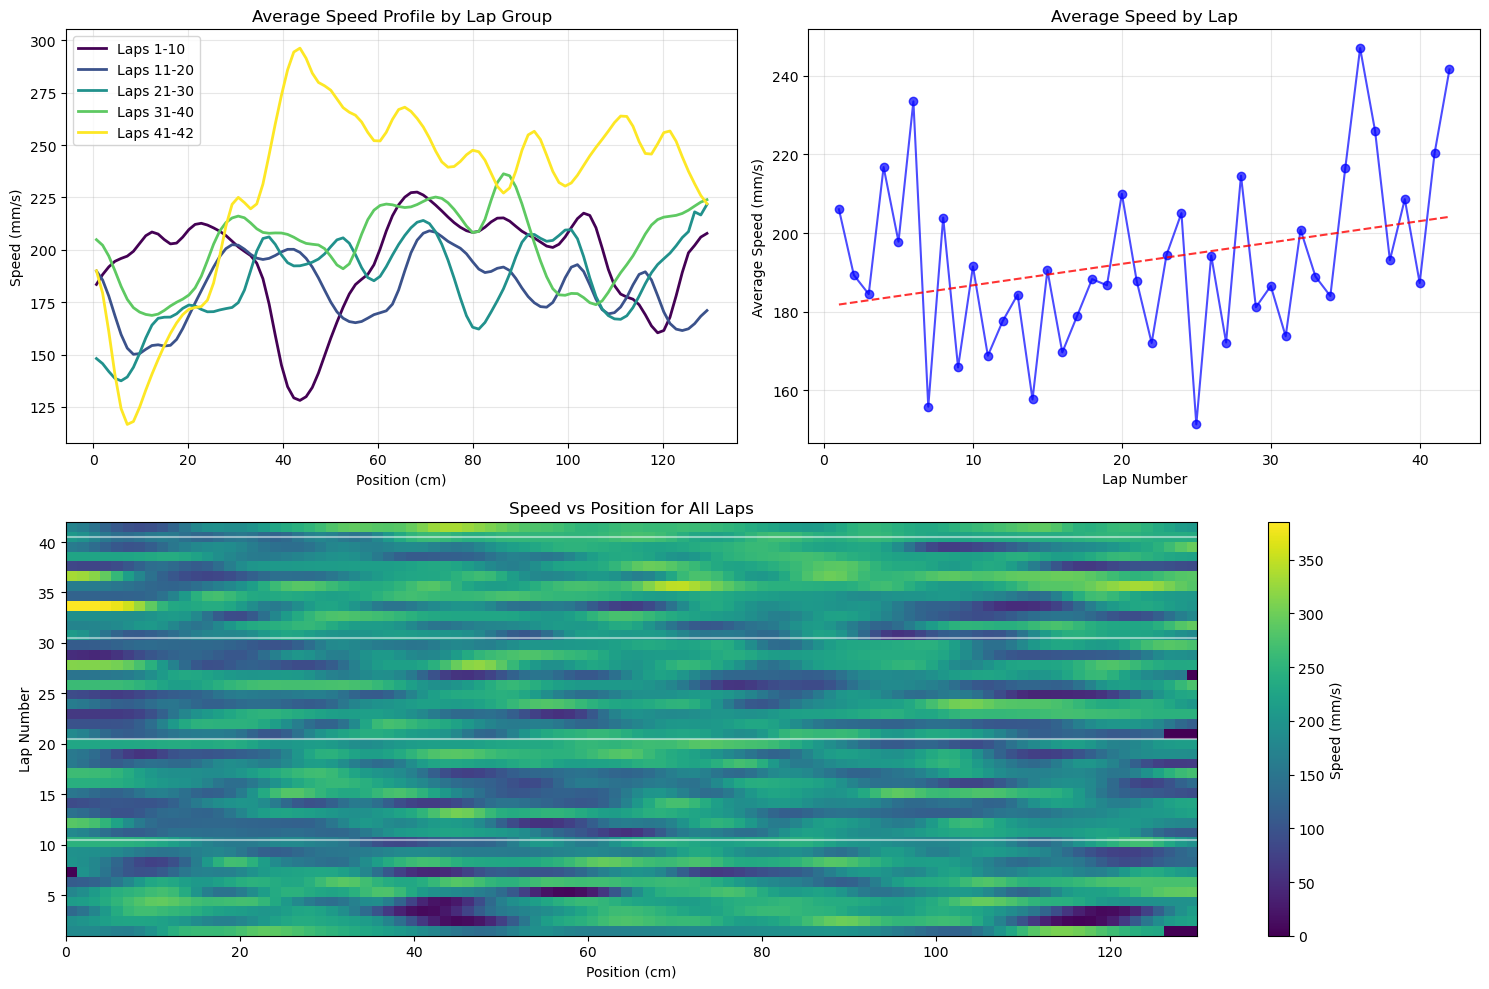

Using deceleration threshold: -2.644
Found 3 significant deceleration regions at positions: 4.6 cm, 76.1 cm, 104.7 cm


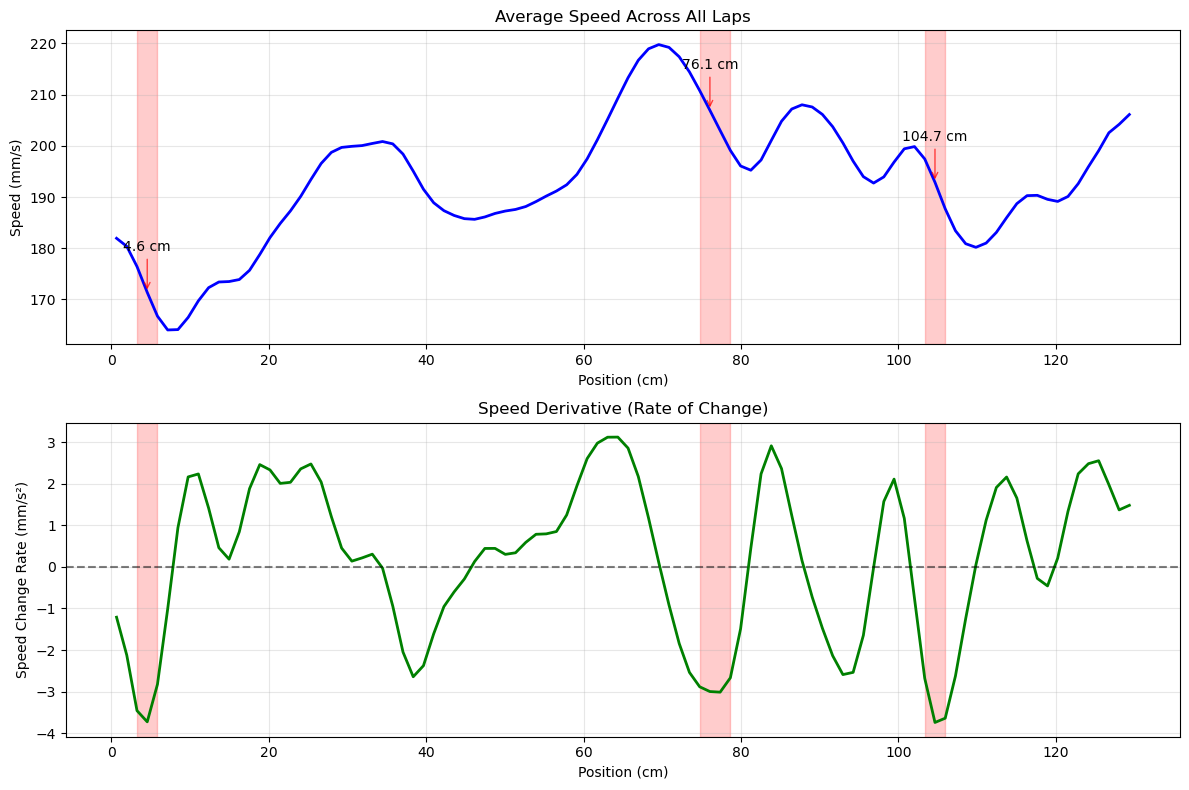


--- ANALYSIS SUMMARY ---
Total laps analyzed: 42
Found 3 positions with significant speed decrease:
  Position: 4.6 cm
  Position: 76.1 cm
  Position: 104.7 cm


In [171]:
 # Paths to your data files
VRlog_path = r"D:\V1_SpatialModulation\V1_SpatialMod_VRLog\VRlog_JSY038_05012025_02-18-59.txt"
treadmill_file_path = r"D:\V1_SpatialModulation\V1_SpatialMod_VRLog\TMlog_05012025_02-18-59.txt"

# Run the comprehensive analysis
results = run_comprehensive_analysis(treadmill_file_path, VRlog_path)